**Template for working with netCDF files** 🌎



> **How to use this code:** <br>
> Run the cells in order to process netCDF files.
>
> Make sure to set-up a directory in your Google Drive where the files live!

*Author: Rebecca G. Topness <br>
Last edit: 20250224*

In [5]:
# Mount your Google Drive
# Running this cell will prompt you to log-in to your Google Account :-)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> We'll use the package called **xarray** to open and manipulate our netCDF files. See the documentation for the package here: https://docs.xarray.dev/en/stable/getting-started-guide/index.html.
>
> Run the cell below to import **xarray** and other packages we'll use to make plots.



In [11]:
import xarray as xr
import matplotlib.pyplot as plt
!pip install cartopy # Install the cartopy caption
import cartopy.crs as ccrs
import numpy as np

> Now we'll load in the datasets. First, set your working directory. This will be the folder where the datasets (netcdfs) are located. <br>
It should start with '/content/drive/MyDrive/' but the folder (called data in the example) might change depending on where you've saved your files! <br>
Here's an example:

```
dir = '/content/drive/MyDrive/data/
```

In [7]:
# Set your working directory here
dir = '/content/drive/MyDrive/process-era5/'

> Let's read in an example netCDF file using **xarray** to check out the file structure.
>
> I just chose a random file:

```
ERA5_NorAm_vcomp_875mb_2021.nc
```



In [8]:
# Read in a netCDF file
ds = xr.open_dataset(dir + '/ERA5_NorAm_vcomp_875mb_2021.nc')

# Look at what the file looks like
ds

<xarray.Dataset> Size: 594MB
Dimensions:    (time: 1460, latitude: 181, longitude: 281)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2021-01-01 ... 2021-12-31T18:00:00
  * latitude   (latitude) float32 724B 60.0 59.75 59.5 59.25 ... 15.5 15.25 15.0
  * longitude  (longitude) float32 1kB -130.0 -129.8 -129.5 ... -60.25 -60.0
Data variables:
    v          (time, latitude, longitude) float64 594MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2022-01-31 22:23:16 GMT by grib_to_netcdf-2.23.0: /opt/ecmw...

> netCDFs are multi-dimensional datasets. They're super helpful because they allow us to bundle a lot of information together into one file.
>
> We see that our file has three dimensions: **time, latitude, and longitude**. The coordinates hold the values of each of the 3 dimensions.
>
> The files cover longitude 60-130 °W and latitude 15-60 °N at 0.25 ° resolution (approx. 25 km) at 6-hourly intervals for each day in the year **2021** (for this file).

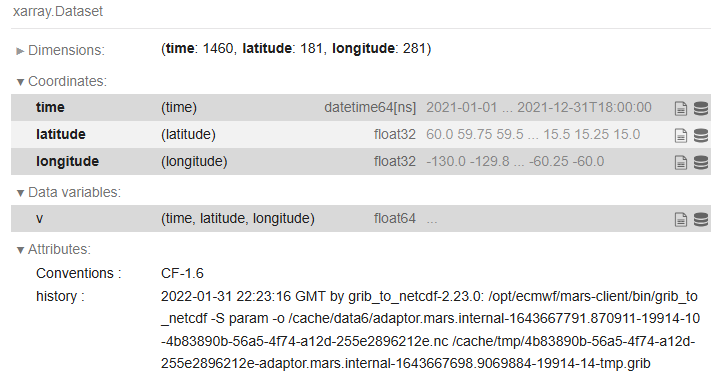


> Now let's take a look at the variable that this netCDF file has.
> We can do this by looking at the **Data variables** in the photo/output above, which we see is "v" across all the dimensions (time, lat, lon).
> Run the cell below to learn more about the variable.

In [9]:
# Check what variable our netCDF has
print(ds.variables.keys())

KeysView(Frozen({'v': <xarray.Variable (time: 1460, latitude: 181, longitude: 281)> Size: 594MB
[74257060 values with dtype=float64]
Attributes:
    units:          m s**-1
    long_name:      V component of wind
    standard_name:  northward_wind, 'longitude': <xarray.IndexVariable 'longitude' (longitude: 281)> Size: 1kB
array([-130.  , -129.75, -129.5 , ...,  -60.5 ,  -60.25,  -60.  ],
      dtype=float32)
Attributes:
    units:      degrees_east
    long_name:  longitude, 'latitude': <xarray.IndexVariable 'latitude' (latitude: 181)> Size: 724B
array([60.  , 59.75, 59.5 , 59.25, 59.  , 58.75, 58.5 , 58.25, 58.  , 57.75,
       57.5 , 57.25, 57.  , 56.75, 56.5 , 56.25, 56.  , 55.75, 55.5 , 55.25,
       55.  , 54.75, 54.5 , 54.25, 54.  , 53.75, 53.5 , 53.25, 53.  , 52.75,
       52.5 , 52.25, 52.  , 51.75, 51.5 , 51.25, 51.  , 50.75, 50.5 , 50.25,
       50.  , 49.75, 49.5 , 49.25, 49.  , 48.75, 48.5 , 48.25, 48.  , 47.75,
       47.5 , 47.25, 47.  , 46.75, 46.5 , 46.25, 46.  , 45.75,

> We see that the variable is the **V component of wind** in units **m/s**, which is the meridional wind (north-south direction).
```
Attributes:
    units:          m s**-1
    long_name:      V component of wind
```



> Now let's make a plot. We'll plot up the V component of wind for one time slice (remember we're dealing with multiple dimensions, so we'll just plot one time across all lats and lons here!).

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


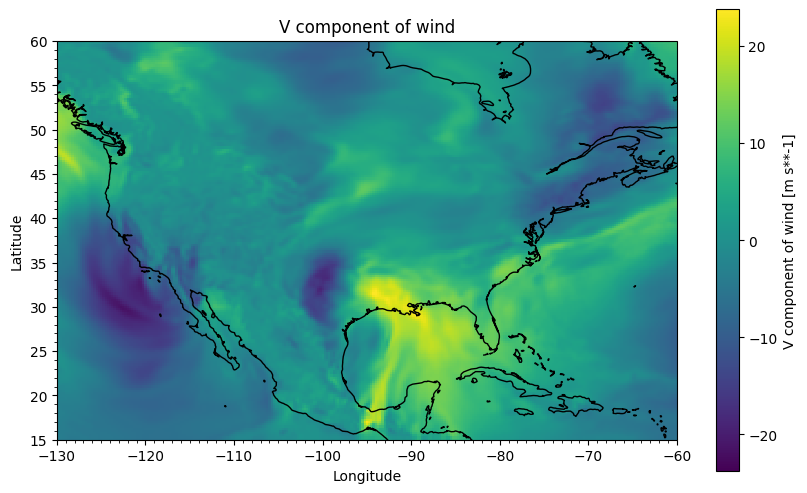

In [10]:
v_comp = ds['v'].isel(time = 0) # We'll grab the first time slice (Python is zero-based, so starts at 0)
# If you change the 'time' value, you can look at another timestep in the dataset!

# Set up the figure
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree()) # This sets the projection of

# Plot the data
v_comp.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis')

# Add map features
ax.coastlines() # This plots the coastlines as black lines
ax.set_xlim(v_comp['longitude'].min(), v_comp['longitude'].max())
ax.set_ylim(v_comp['latitude'].min(), v_comp['latitude'].max())
ax.set_xticks(np.arange(v_comp['longitude'].min(), v_comp['longitude'].max()), 20)
ax.set_yticks(np.arange(v_comp['latitude'].min(), v_comp['latitude'].max()), 20)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('V component of wind')

# Show the plot
plt.show()

> Let's read in the U component (zonal, or east-west) of wind and calculate windspeed. Windspeed is calculated by combining the V and U components using the Pythagorean theorem.

```
windspeed = np.sqrt(u_comp*u_comp + v_comp*v_comp)
```

In [14]:
# Read in a netCDF file
ds2 = xr.open_dataset(dir + '/ERA5_NorAm_ucomp_875mb_2021.nc')

windspeed = np.sqrt(ds2.u**2 + ds.v**2)

> Now plot windspeed as a contour map.

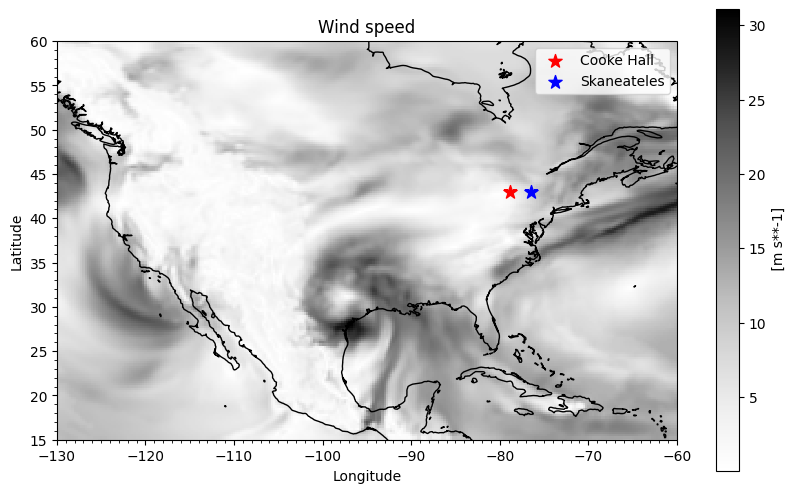

In [42]:
values = windspeed.isel(time = 0) # We'll grab the first time slice (Python is zero-based, so starts at 0)
# If you change the 'time' value, you can look at another timestep in the dataset!

# Set up the figure
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree()) # This sets the projection of

# Plot the data
values.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Greys')

ax.scatter(-78.79, 43, color='red', marker='*', s=100, transform=ccrs.PlateCarree(), label = "Cooke Hall")
ax.scatter(-76.43, 42.95, color = 'blue', marker = '*', s = 100, transform=ccrs.PlateCarree(), label = "Skaneateles")
ax.legend(loc='upper right')

# Add map features
ax.coastlines() # This plots the coastlines as black lines
ax.set_xlim(v_comp['longitude'].min(), v_comp['longitude'].max())
ax.set_ylim(v_comp['latitude'].min(), v_comp['latitude'].max())
ax.set_xticks(np.arange(v_comp['longitude'].min(), v_comp['longitude'].max()), 20)
ax.set_yticks(np.arange(v_comp['latitude'].min(), v_comp['latitude'].max()), 20)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Wind speed')

# Show the plot
plt.show()

> Wait, but we don't want the entire United States! Let's select only the grid cells near our study sites to plot.
> We do this using *.sel*, which is an important feature in **xarray** that lets us subset our datasets. <br>
>
> Recall that the files cover longitude 60-130 °W and latitude 15-60 °N at 0.25 ° resolution (approx. 25 km). We can use *.sel* to extract the nearest grid cell to each of our sites, UB and Skaneateles.

```
Skaneateles: 42.95 latitude, -76.43 longitude
Cooke Hall: 43 latitude, -78.79 longitude
```

In [43]:
skan = windspeed.sel(latitude = 42, longitude = -76.43, method = 'nearest') # Method = 'nearest' grabs the grid cell that is closest to our lat, lon point
cooke = windspeed.sel(latitude = 43, longitude = -78.79, method = 'nearest')

> Now we can plot a timeseries of windspeed for our sites.

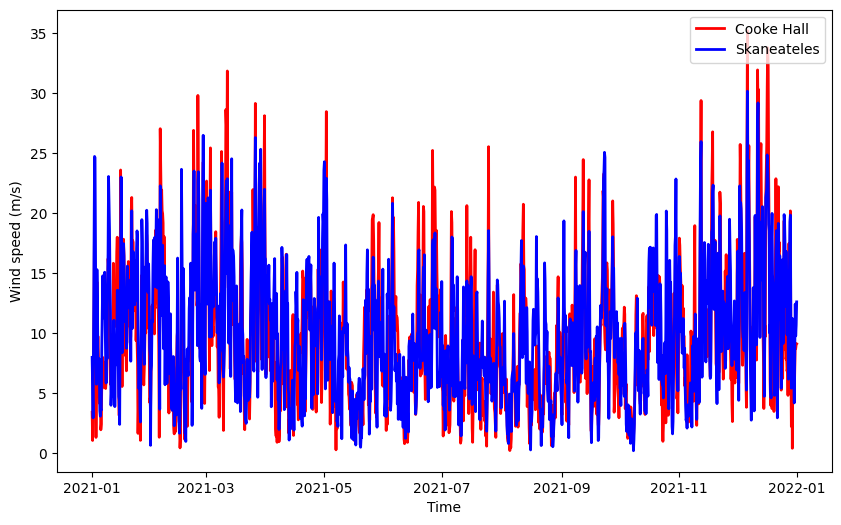

In [46]:
# Set up the figure
plt.figure(figsize=(10, 6))

# Plot the data
plt.plot(cooke.time, cooke, color = 'red', linewidth = 2, label = "Cooke Hall")
plt.plot(skan.time, skan, color = 'blue', linewidth = 2, label = "Skaneateles")

plt.legend(loc='upper right')

plt.xlabel('Time')
plt.ylabel('Wind speed (m/s)')

# Show the plot
plt.show()

Xarray has a bunch of tutorials which might also be helpful! https://docs.xarray.dev/en/stable/getting-started-guide/tutorials-and-videos.html